# 05 · From scores to decisions — cost-optimal thresholds

A detector score is a number. **An operator needs a decision**: alarm or wait. The right threshold depends on the **economic cost** of being wrong each way.

In [1]:
import sensorlab  # set OMP env vars before torch/xgboost load
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (9, 4)})


In [2]:
from sensorlab.data import (load_dataset, SyntheticTEPConfig, Standardizer,
                           train_val_test_split_by_run)
from sensorlab.detection import PCAMonitor, IForestDetector
from sensorlab.decision import CostModel, cost_curve, optimal_threshold
from sensorlab.viz import plot_cost_curve

cfg = SyntheticTEPConfig(n_normal_runs=12, n_runs_per_fault=4, fault_run_minutes=480, seed=0)
ds = load_dataset("synthetic", cfg=cfg)
train_m, _, test_m = train_val_test_split_by_run(ds, seed=0)
sc = Standardizer.fit(ds.X[train_m & (ds.fault_id == 0)]); Xz = sc.transform(ds.X)
ifo = IForestDetector(n_estimators=200, random_state=0).fit(Xz[train_m & (ds.fault_id == 0)])
scores = ifo.score(Xz)

## Cost curve under a reference operating cost model

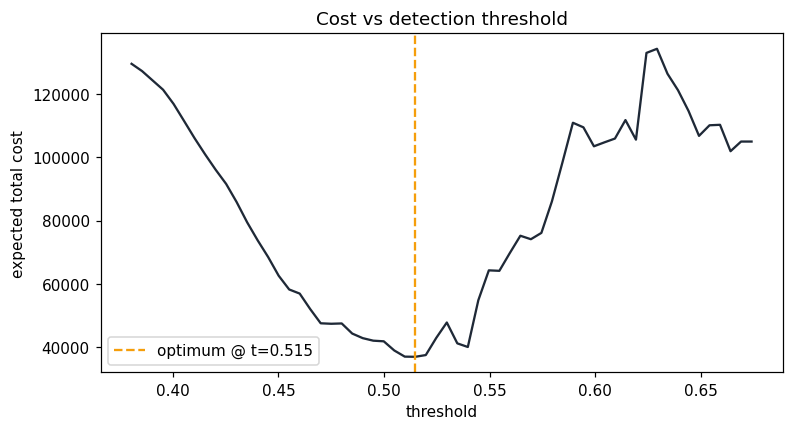

optimum thr=0.515  expected_cost=36900 CHF
   FA=126  missed=0  delay=23.1 min


In [3]:
cost = CostModel(false_alarm_cost=100.0, missed_fault_cost=5000.0, delay_cost_per_min=50.0)
grid, results = cost_curve(scores[test_m], ds.run_id[test_m], ds.run_onsets, ds.run_fault_id,
                           cost=cost, n_grid=60, samples_to_minutes=ds.sample_minutes)
fig, ax = plt.subplots(figsize=(8, 4))
plot_cost_curve(grid, results, ax=ax); plt.show()

best = optimal_threshold(scores[test_m], ds.run_id[test_m], ds.run_onsets, ds.run_fault_id,
                         cost=cost, n_grid=60, samples_to_minutes=ds.sample_minutes)
print(f"optimum thr={best.threshold:.3f}  expected_cost={best.expected_cost:.0f} CHF")
print(f"   FA={best.false_alarms}  missed={best.missed_faults}  delay={best.mean_delay_min:.1f} min")

## What if the operating cost shifts?

Different process units have different cost profiles. A reactor where a missed fault means a scrapped batch is willing to tolerate more false alarms than a polishing step where false alarms stop a production line.

In [4]:
rows = []
for fa_cost in [25, 100, 500]:
    for mf_cost in [1_000, 5_000, 20_000]:
        c = CostModel(false_alarm_cost=fa_cost, missed_fault_cost=mf_cost, delay_cost_per_min=20.0)
        r = optimal_threshold(scores[test_m], ds.run_id[test_m], ds.run_onsets, ds.run_fault_id,
                              cost=c, samples_to_minutes=ds.sample_minutes)
        rows.append({"FA_cost": fa_cost, "MF_cost": mf_cost,
                    "thr": round(r.threshold, 3), "exp_cost_CHF": round(r.expected_cost, 0),
                    "FA": r.false_alarms, "missed": r.missed_faults,
                    "mean_delay_min": round(r.mean_delay_min, 1)})
pd.DataFrame(rows)

,FA_cost,MF_cost,thr,exp_cost_CHF,FA,missed,mean_delay_min
0,25,1000,0.510,12455.0,155,0,20.4
1,25,5000,0.510,12455.0,155,0,20.4
2,25,20000,0.510,12455.0,155,0,20.4
3,100,1000,0.540,18000.0,50,1,30.0
4,100,5000,0.520,21340.0,106,0,25.6
5,100,20000,0.520,21340.0,106,0,25.6
6,500,1000,0.664,20780.0,0,20,39.0
7,500,5000,0.540,42000.0,50,1,30.0
8,500,20000,0.530,54520.0,77,0,38.1


**Takeaways**

- A detector + a threshold isn't a complete decision; it must be paired with a cost model the business owns.
- The optimum threshold shifts predictably: when false alarms are cheap, lower the bar; when missed faults are expensive, lower the bar further.
- The Streamlit dashboard (`make app`) lets a process engineer slide the cost knobs and read the new optimum in real time.